In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# jdcnet_dynamic_qbits.py
# JDCNet with DYNAMIC quantization bits based on channel SNR.
# Only change from original: snr_to_bits() + passing quant_bits dynamically
# during train, val, and test. No architecture changes.
# this is all for quanitzation and with n=4 , n=2 literally sames codes like duh 

import os, random, math, time, shutil
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ---------------- reproducibility ----------------
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------------ #
#  NEW: Dynamic quantization bit selector                             #
#  Low SNR  → fewer bits (noisy estimate, precision is wasted)        #
#  High SNR → more bits  (clean estimate, worth preserving detail)    #
#  Mapping  : SNR 0 dB  → min_bits (2)                               #
#             SNR 35 dB → max_bits (8)                               #
# ------------------------------------------------------------------ #
def snr_to_bits(snr_db, min_bits=2, max_bits=8, snr_min=0.0, snr_max=35.0):
    """Linearly map SNR (dB) to quantization bit-depth."""
    ratio = (snr_db - snr_min) / (snr_max - snr_min)
    ratio = max(0.0, min(1.0, ratio))           # clamp to [0,1]
    bits  = min_bits + (max_bits - min_bits) * ratio
    return int(round(bits))

# ---------------- flexible loader helper ----------------
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)

    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if 'model_state_dict' in sd:
            sd = sd['model_state_dict']
        elif 'state_dict' in sd:
            sd = sd['state_dict']

    if not isinstance(sd, dict):
        raise RuntimeError(f"Loaded object from {path} is not a state_dict mapping.")

    sd_keys = list(sd.keys())
    if len(sd_keys) == 0:
        raise RuntimeError("Loaded state_dict is empty")

    saved_has_module = sd_keys[0].startswith('module.')
    model_is_datapar = isinstance(model, nn.DataParallel)

    if verbose:
        print(f"[loader] Loaded state_dict from {path}. "
              f"saved_has_module={saved_has_module}, model_is_datapar={model_is_datapar}")

    if saved_has_module and not model_is_datapar:
        sd = {k[len('module.'):]: v for k, v in sd.items()}
        if verbose: print("[loader] Stripped 'module.' prefix from saved keys.")
    elif (not saved_has_module) and model_is_datapar:
        sd = {'module.' + k: v for k, v in sd.items()}
        if verbose: print("[loader] Added 'module.' prefix to saved keys to match DataParallel model.")

    try:
        model.load_state_dict(sd)
        if verbose: print("[loader] State dict loaded successfully (strict).")
    except Exception as e:
        if verbose:
            print("[loader] Strict load failed. Attempting non-strict load for diagnostics...")
        res = model.load_state_dict(sd, strict=False)
        if verbose:
            print("[loader] Non-strict load result:", res)
        raise e

# ---------------- STE Quantizer ----------------
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        levels    = 2 ** q_bits - 1
        x_clamped = torch.clamp(x, 0.0, 1.0)
        q         = torch.round(x_clamped * levels) / levels
        return q
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# ---------------- ResBlock (unchanged) ----------------
class PaperResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        identity = x
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return self.relu(out + identity)

# ---------------- JDCNet (unchanged architecture) ----------------
class JDCNet_Paper(nn.Module):
    def __init__(self, M=16, N=64, N0=2, gamma=1/16, q_bits=8,
                 B=4, decoder_ch=16, quant_enabled=True):
        super().__init__()
        self.M, self.N, self.N0 = M, N, N0
        self.Np             = N // N0
        self.q_bits         = q_bits
        self.quant_enabled  = quant_enabled
        self.C              = int(gamma * 32 * N0)

        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16,     kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, self.C, kernel_size=4, stride=2, padding=1)
        )

        self.decoder_tconv1 = nn.ConvTranspose2d(self.C, decoder_ch,
                                                  kernel_size=4, stride=2, padding=1)
        self.decoder_tconv2 = nn.ConvTranspose2d(decoder_ch, decoder_ch,
                                                  kernel_size=4, stride=2, padding=1)
        self.resblocks       = nn.Sequential(*[PaperResBlock(decoder_ch) for _ in range(B)])
        self.final_tconv     = nn.ConvTranspose2d(
            decoder_ch, decoder_ch,
            kernel_size=(1, 2 * N0), stride=(1, N0), padding=(0, N0 // 2)
        )
        self.final_conv      = nn.Conv2d(decoder_ch, 2, kernel_size=3, padding=1)

    def forward(self, x_norm, quant_bits=None):
        b       = x_norm.shape[0]
        z       = self.encoder(x_norm)
        z_shape = z.shape
        v       = z.view(b, -1)

        v_min = v.min(dim=1, keepdim=True)[0]
        v_max = v.max(dim=1, keepdim=True)[0]
        denom = (v_max - v_min).clamp_min(1e-12)

        if self.quant_enabled:
            # quant_bits is now supplied dynamically per batch/SNR
            qbits  = self.q_bits if quant_bits is None else quant_bits
            v_norm = (v - v_min) / denom
            v_q    = QuantizeSTE.apply(v_norm, qbits)
            v_deq  = v_q * denom + v_min
        else:
            v_deq = v

        z_deq = v_deq.view(*z_shape)
        y     = torch.relu(self.decoder_tconv1(z_deq))
        y     = torch.relu(self.decoder_tconv2(y))
        y     = self.resblocks(y)
        y     = torch.relu(self.final_tconv(y))
        out   = self.final_conv(y)
        return out

# ---------------- Dataset (unchanged) ----------------
class RISChannelDataset(Dataset):
    def __init__(self, mat_file, split='train'):
        data      = sio.loadmat(mat_file)
        H_mat     = np.transpose(data['H'], (2, 0, 1)).astype(np.complex64)
        G_mat     = np.transpose(data['G'], (2, 0, 1)).astype(np.complex64)
        H_cascade = G_mat.transpose(0, 2, 1) * H_mat

        if split == 'train':
            samples = H_cascade[:40000]
        elif split == 'val':
            samples = H_cascade[40000:44000]
        else:
            samples = H_cascade[44000:48000]

        real    = np.real(samples).astype(np.float32)
        imag    = np.imag(samples).astype(np.float32)
        stacked = np.stack([real, imag], axis=1)
        stacked = stacked.transpose(0, 1, 3, 2)
        self.data_phys = torch.tensor(stacked, dtype=torch.float32)

    def __len__(self):            return len(self.data_phys)
    def __getitem__(self, idx):   return self.data_phys[idx]

# ---------------- LS generator (unchanged) ----------------
def generate_ls_physical(H_phys, N0, snr_db):
    b, c, m, n    = H_phys.shape
    assert n % N0 == 0
    H_grouped     = H_phys.view(b, c, m, n // N0, N0).mean(dim=-1)
    power_per_sample = torch.mean(H_grouped[:, 0]**2 + H_grouped[:, 1]**2, dim=[1, 2])
    snr_linear    = 10.0 ** (snr_db / 10.0)
    noise_var     = power_per_sample / snr_linear
    noise_std     = torch.sqrt(noise_var / 2.0).view(b, 1, 1, 1)
    noise         = torch.randn_like(H_grouped) * noise_std
    return H_grouped + noise

# ---------------- LR schedule (unchanged) ----------------
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * (epoch / max(1, Tw))
    else:
        t_rel = (epoch - Tw) / max(1, (T - Tw))
        return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * t_rel))

# ---------------- Full pipeline ----------------
def run_paper_pipeline(mat_path='/kaggle/input/datasets/hades1998/dataset-mlwl/RIS_Channels_1.mat',
                       N0=4, gamma=1/16, q_bits=8,
                       batch_size=256, epochs=200, Tw=30, eta_max=2e-3, eta_min=5e-5,
                       device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)

    train_ds = RISChannelDataset(mat_path, 'train')
    val_ds   = RISChannelDataset(mat_path, 'val')
    test_ds  = RISChannelDataset(mat_path, 'test')

    train_min = float(train_ds.data_phys.min())
    train_max = float(train_ds.data_phys.max())
    print(f"Global train min/max: min={train_min:.6e}, max={train_max:.6e}")

    def minmax_norm(x):
        return (x - train_min) / (train_max - train_min + 1e-12)
    def minmax_denorm(x):
        return x * (train_max - train_min) + train_min

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)

    model = JDCNet_Paper(M=16, N=64, N0=N0, gamma=gamma, q_bits=q_bits,
                         B=4, decoder_ch=16, quant_enabled=True)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(device)

    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_val_nmse = 1e9
    best_path     = '/kaggle/working/jdcnet_dynamic_qbits_best.pth'
    out_path      = '/kaggle/output/jdcnet_dynamic_qbits_best.pth'

    print(f"Training with DYNAMIC q-bits | epochs={epochs} | batch_size={batch_size}")

    for epoch in range(epochs):
        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups:
            g['lr'] = lr

        train_loss = 0.0
        t0 = time.time()

        for batch in train_loader:
            batch = batch.to(device)

            # --- CHANGE 1: sample SNR then derive bits dynamically ---
            snr_train = random.uniform(10, 30)
            qbits     = snr_to_bits(snr_train)          # <-- dynamic bits

            H_ls_phys  = generate_ls_physical(batch, N0=N0, snr_db=snr_train)
            H_ls_norm  = minmax_norm(H_ls_phys).to(device)
            H_orig_norm = minmax_norm(batch).to(device)

            optimizer.zero_grad()
            out_norm = model(H_ls_norm, quant_bits=qbits)   # <-- pass bits
            loss     = criterion(out_norm, H_orig_norm)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        t1 = time.time()

        # ---- Validation (fixed SNR=15 dB → 5 bits) ----
        val_snr   = 15.0
        val_qbits = snr_to_bits(val_snr)               # <-- CHANGE 2: dynamic val bits

        model.eval()
        val_mse   = 0.0
        val_power = 0.0
        with torch.no_grad():
            for vb in val_loader:
                vb       = vb.to(device)
                H_ls_p   = generate_ls_physical(vb, N0=N0, snr_db=val_snr)
                H_ls_n   = minmax_norm(H_ls_p).to(device)
                out_n    = model(H_ls_n, quant_bits=val_qbits)   # <-- pass bits
                out_phys = minmax_denorm(out_n.cpu())
                val_mse   += torch.sum((out_phys.to(device) - vb) ** 2).item()
                val_power += torch.sum(vb ** 2).item()

        val_nmse_db = 10.0 * math.log10(val_mse / (val_power + 1e-12))

        if val_nmse_db < best_val_nmse:
            best_val_nmse = val_nmse_db
            model_state   = (model.module.state_dict()
                             if isinstance(model, nn.DataParallel)
                             else model.state_dict())
            torch.save(model_state, best_path)
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                if os.path.exists(best_path):
                    shutil.copy(best_path, out_path)
            except Exception:
                pass

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | lr={lr:.2e} | "
                  f"train_loss={train_loss:.4e} | val_NMSE={val_nmse_db:.3f} dB | "
                  f"best={best_val_nmse:.3f} dB | t={t1-t0:.1f}s")

    # ---- Load best checkpoint ----
    load_state_dict_flexible(best_path, model, map_location=device, verbose=True)
    model.eval()

    # ---- Test evaluation (dynamic bits per SNR point) ----
    snrs         = [0, 5, 10, 15, 20, 25, 30, 35]
    nmse_results = []

    print("\nTest results (dynamic q-bits per SNR):")
    with torch.no_grad():
        for snr in snrs:
            qbits       = snr_to_bits(snr)             # <-- CHANGE 3: dynamic test bits
            total_mse   = 0.0
            total_power = 0.0

            for tb in test_loader:
                tb         = tb.to(device)
                H_ls_phys  = generate_ls_physical(tb, N0=N0, snr_db=snr)
                H_ls_norm  = minmax_norm(H_ls_phys).to(device)
                out_norm   = model(H_ls_norm, quant_bits=qbits)    # <-- pass bits
                out_phys   = minmax_denorm(out_norm.cpu())
                total_mse   += torch.sum((out_phys.to(device) - tb) ** 2).item()
                total_power += torch.sum(tb ** 2).item()

            nmse_db = 10.0 * math.log10(total_mse / (total_power + 1e-12))
            nmse_results.append(nmse_db)
            print(f"  SNR {snr:2d} dB | q_bits={qbits} | NMSE={nmse_db:.3f} dB")

    # ---- Plot ----
    plt.figure(figsize=(8, 5))
    plt.plot(snrs, nmse_results, 'r-o', label='JDCNet (N0=4, dynamic q-bits)')
    plt.plot(snrs, [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74],
             'b--s', label='Paper benchmark (fixed 8-bit)')
    plt.xlabel('SNR (dB)')
    plt.ylabel('NMSE (dB)')
    plt.title('JDCNet — Dynamic Quantization vs Paper Benchmark')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return model, nmse_results

# ---------------- Entry point ----------------
if __name__ == '__main__':
    mat_path = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat'
    model, res = run_paper_pipeline(
        mat_path   = mat_path,
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,          # used as default/fallback only
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5
    )

In [ ]:
# jdcnet_v3.py
# JDCNet with three targeted improvements:
#   1. SNR Conditioning  — decoder is told the SNR explicitly
#   2. B=6 ResBlocks     — more decoder capacity, fixes high-SNR plateau
#   3. Curriculum Training — easy (high SNR) first, full range later
#   + Gradient clipping  — free stability improvement
#this is with what claude thought my goatest being 
# Dynamic q-bits kept as it reduces feedback overhead even if NMSE gain is small.

import os, random, math, time, shutil
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ---------------- reproducibility ----------------
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------------ #
#  Dynamic q-bits (kept from v2)                                      #
# ------------------------------------------------------------------ #
def snr_to_bits(snr_db, min_bits=2, max_bits=8, snr_min=0.0, snr_max=35.0):
    ratio = (snr_db - snr_min) / (snr_max - snr_min)
    ratio = max(0.0, min(1.0, ratio))
    return int(round(min_bits + (max_bits - min_bits) * ratio))

# ------------------------------------------------------------------ #
#  IMPROVEMENT 3: Curriculum SNR sampler                              #
#  Early epochs → high SNR only (easy, clean signal)                 #
#  Later epochs → full range 0–30 dB (harder, noisy signal)          #
# ------------------------------------------------------------------ #
def curriculum_snr(epoch, total_epochs, snr_floor=0.0, snr_ceil=30.0, warmup_frac=0.4):
    """
    For the first `warmup_frac` of training, SNR minimum rises from
    snr_ceil down to snr_floor (easy → hard). After that, full range.
    """
    warmup_epochs = int(total_epochs * warmup_frac)
    if epoch < warmup_epochs:
        # snr_min starts at snr_ceil (easy), linearly drops to snr_floor
        snr_min = snr_ceil - (snr_ceil - snr_floor) * (epoch / max(1, warmup_epochs))
    else:
        snr_min = snr_floor
    return random.uniform(snr_min, snr_ceil)

# ---------------- flexible loader ----------------
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)

    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if 'model_state_dict' in sd:
            sd = sd['model_state_dict']
        elif 'state_dict' in sd:
            sd = sd['state_dict']

    if not isinstance(sd, dict):
        raise RuntimeError(f"Loaded object from {path} is not a state_dict mapping.")

    sd_keys = list(sd.keys())
    if len(sd_keys) == 0:
        raise RuntimeError("Loaded state_dict is empty")

    saved_has_module = sd_keys[0].startswith('module.')
    model_is_datapar = isinstance(model, nn.DataParallel)

    if verbose:
        print(f"[loader] saved_has_module={saved_has_module}, "
              f"model_is_datapar={model_is_datapar}")

    if saved_has_module and not model_is_datapar:
        sd = {k[len('module.'):]: v for k, v in sd.items()}
        if verbose: print("[loader] Stripped 'module.' prefix.")
    elif (not saved_has_module) and model_is_datapar:
        sd = {'module.' + k: v for k, v in sd.items()}
        if verbose: print("[loader] Added 'module.' prefix.")

    try:
        model.load_state_dict(sd)
        if verbose: print("[loader] Loaded successfully (strict).")
    except Exception as e:
        if verbose: print("[loader] Strict failed, trying non-strict...")
        res = model.load_state_dict(sd, strict=False)
        if verbose: print("[loader] Non-strict result:", res)
        raise e

# ---------------- STE Quantizer (unchanged) ----------------
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        levels    = 2 ** q_bits - 1
        x_clamped = torch.clamp(x, 0.0, 1.0)
        return torch.round(x_clamped * levels) / levels
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# ---------------- ResBlock (unchanged) ----------------
class PaperResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return self.relu(out + x)

# ------------------------------------------------------------------ #
#  IMPROVEMENT 1: SNR Conditioning                                    #
#  A small MLP embeds the scalar SNR value into a feature vector      #
#  that is added to the decoder's spatial feature maps (FiLM-style).  #
#  The decoder now *knows* how noisy its input is and can adjust      #
#  its reconstruction strategy accordingly.                           #
# ------------------------------------------------------------------ #
class SNRConditioner(nn.Module):
    def __init__(self, decoder_ch, snr_min=0.0, snr_max=35.0):
        super().__init__()
        self.snr_min = snr_min
        self.snr_max = snr_max
        # MLP: scalar SNR → (decoder_ch,) scale + bias (FiLM parameters)
        self.mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, decoder_ch * 2)   # first half=scale, second half=bias
        )
        self.decoder_ch = decoder_ch

    def forward(self, y, snr_db):
        """
        y      : (B, decoder_ch, H, W)
        snr_db : scalar float  — the SNR for this batch
        """
        b = y.shape[0]
        # Normalise SNR to [0,1] for stable MLP input
        snr_norm = torch.tensor(
            [(snr_db - self.snr_min) / (self.snr_max - self.snr_min)],
            dtype=torch.float32, device=y.device
        ).unsqueeze(0).expand(b, -1)                     # (B, 1)

        params  = self.mlp(snr_norm)                     # (B, 2*decoder_ch)
        scale   = params[:, :self.decoder_ch].view(b, self.decoder_ch, 1, 1) + 1.0
        bias    = params[:, self.decoder_ch:].view(b, self.decoder_ch, 1, 1)
        return y * scale + bias                          # FiLM modulation

# ------------------------------------------------------------------ #
#  JDCNet v3                                                          #
#  Changes vs original:                                               #
#    - B default raised to 6          (IMPROVEMENT 2)                 #
#    - SNRConditioner injected after  (IMPROVEMENT 1)                 #
#      the ResBlock stack                                             #
# ------------------------------------------------------------------ #
class JDCNet_V3(nn.Module):
    def __init__(self, M=16, N=64, N0=2, gamma=1/16, q_bits=8,
                 B=6, decoder_ch=16, quant_enabled=True,
                 snr_min=0.0, snr_max=35.0):
        super().__init__()
        self.M, self.N, self.N0 = M, N, N0
        self.Np            = N // N0
        self.q_bits        = q_bits
        self.quant_enabled = quant_enabled
        self.C             = int(gamma * 32 * N0)

        # ---- Encoder (unchanged) ----
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16,      kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, self.C, kernel_size=4, stride=2, padding=1)
        )

        # ---- Decoder (unchanged structure) ----
        self.decoder_tconv1 = nn.ConvTranspose2d(self.C, decoder_ch,
                                                  kernel_size=4, stride=2, padding=1)
        self.decoder_tconv2 = nn.ConvTranspose2d(decoder_ch, decoder_ch,
                                                  kernel_size=4, stride=2, padding=1)

        # IMPROVEMENT 2: B=6 instead of B=4
        self.resblocks = nn.Sequential(*[PaperResBlock(decoder_ch) for _ in range(B)])

        # IMPROVEMENT 1: SNR conditioning injected after ResBlocks
        self.snr_cond = SNRConditioner(decoder_ch, snr_min=snr_min, snr_max=snr_max)

        self.final_tconv = nn.ConvTranspose2d(
            decoder_ch, decoder_ch,
            kernel_size=(1, 2 * N0), stride=(1, N0), padding=(0, N0 // 2)
        )
        self.final_conv = nn.Conv2d(decoder_ch, 2, kernel_size=3, padding=1)

    def forward(self, x_norm, quant_bits=None, snr_db=None):
        b       = x_norm.shape[0]
        z       = self.encoder(x_norm)
        z_shape = z.shape
        v       = z.view(b, -1)

        v_min = v.min(dim=1, keepdim=True)[0]
        v_max = v.max(dim=1, keepdim=True)[0]
        denom = (v_max - v_min).clamp_min(1e-12)

        if self.quant_enabled:
            qbits  = self.q_bits if quant_bits is None else quant_bits
            v_norm = (v - v_min) / denom
            v_q    = QuantizeSTE.apply(v_norm, qbits)
            v_deq  = v_q * denom + v_min
        else:
            v_deq = v

        z_deq = v_deq.view(*z_shape)

        y = torch.relu(self.decoder_tconv1(z_deq))
        y = torch.relu(self.decoder_tconv2(y))
        y = self.resblocks(y)

        # IMPROVEMENT 1: apply SNR conditioning if SNR is provided
        if snr_db is not None:
            y = self.snr_cond(y, snr_db)

        y   = torch.relu(self.final_tconv(y))
        out = self.final_conv(y)
        return out

# ---------------- Dataset (unchanged) ----------------
class RISChannelDataset(Dataset):
    def __init__(self, mat_file, split='train'):
        data      = sio.loadmat(mat_file)
        H_mat     = np.transpose(data['H'], (2, 0, 1)).astype(np.complex64)
        G_mat     = np.transpose(data['G'], (2, 0, 1)).astype(np.complex64)
        H_cascade = G_mat.transpose(0, 2, 1) * H_mat

        if split == 'train':
            samples = H_cascade[:40000]
        elif split == 'val':
            samples = H_cascade[40000:44000]
        else:
            samples = H_cascade[44000:48000]

        real    = np.real(samples).astype(np.float32)
        imag    = np.imag(samples).astype(np.float32)
        stacked = np.stack([real, imag], axis=1).transpose(0, 1, 3, 2)
        self.data_phys = torch.tensor(stacked, dtype=torch.float32)

    def __len__(self):          return len(self.data_phys)
    def __getitem__(self, idx): return self.data_phys[idx]

# ---------------- LS generator (unchanged) ----------------
def generate_ls_physical(H_phys, N0, snr_db):
    b, c, m, n      = H_phys.shape
    H_grouped       = H_phys.view(b, c, m, n // N0, N0).mean(dim=-1)
    power_per_sample = torch.mean(H_grouped[:, 0]**2 + H_grouped[:, 1]**2, dim=[1, 2])
    snr_linear      = 10.0 ** (snr_db / 10.0)
    noise_var       = power_per_sample / snr_linear
    noise_std       = torch.sqrt(noise_var / 2.0).view(b, 1, 1, 1)
    return H_grouped + torch.randn_like(H_grouped) * noise_std

# ---------------- LR schedule (unchanged) ----------------
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * (epoch / max(1, Tw))
    t_rel = (epoch - Tw) / max(1, (T - Tw))
    return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * t_rel))

# ---------------- Full pipeline ----------------
def run_pipeline_v3(
        mat_path   = '/kaggle/input/datasets/hades1998/dataset-mlwl/RIS_Channels_1.mat',
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5,
        device     = None):

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)

    train_ds = RISChannelDataset(mat_path, 'train')
    val_ds   = RISChannelDataset(mat_path, 'val')
    test_ds  = RISChannelDataset(mat_path, 'test')

    train_min = float(train_ds.data_phys.min())
    train_max = float(train_ds.data_phys.max())
    print(f"Global train min/max: {train_min:.4e} / {train_max:.4e}")

    def minmax_norm(x):
        return (x - train_min) / (train_max - train_min + 1e-12)
    def minmax_denorm(x):
        return x * (train_max - train_min) + train_min

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)

    # IMPROVEMENT 2: B=6
    model = JDCNet_V3(M=16, N=64, N0=N0, gamma=gamma, q_bits=q_bits,
                      B=6, decoder_ch=16, quant_enabled=True,
                      snr_min=0.0, snr_max=35.0)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(device)

    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_val_nmse = 1e9
    best_path     = '/kaggle/working/jdcnet_v3_best.pth'
    out_path      = '/kaggle/output/jdcnet_v3_best.pth'

    print(f"\nTraining JDCNet v3 | epochs={epochs} | batch={batch_size} "
          f"| B=6 | SNR-conditioned | curriculum SNR")
    print("-" * 70)

    for epoch in range(epochs):
        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups:
            g['lr'] = lr

        train_loss = 0.0
        t0 = time.time()

        for batch in train_loader:
            batch = batch.to(device)

            # IMPROVEMENT 3: curriculum SNR — easy first, hard later
            snr_train = curriculum_snr(epoch, epochs,
                                       snr_floor=0.0, snr_ceil=35.0,
                                       warmup_frac=0.4)
            qbits     = snr_to_bits(snr_train)

            H_ls_phys  = generate_ls_physical(batch, N0=N0, snr_db=snr_train)
            H_ls_norm  = minmax_norm(H_ls_phys).to(device)
            H_orig_norm = minmax_norm(batch).to(device)

            optimizer.zero_grad()

            # IMPROVEMENT 1: pass snr_db so decoder can condition on it
            out_norm = model(H_ls_norm, quant_bits=qbits, snr_db=snr_train)
            loss     = criterion(out_norm, H_orig_norm)
            loss.backward()

            # Gradient clipping — free stability improvement
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        t1 = time.time()

        # ---- Validation at fixed SNR=15 dB ----
        val_snr   = 15.0
        val_qbits = snr_to_bits(val_snr)
        model.eval()
        val_mse = val_power = 0.0

        with torch.no_grad():
            for vb in val_loader:
                vb       = vb.to(device)
                H_ls_p   = generate_ls_physical(vb, N0=N0, snr_db=val_snr)
                H_ls_n   = minmax_norm(H_ls_p).to(device)
                out_n    = model(H_ls_n, quant_bits=val_qbits, snr_db=val_snr)
                out_phys = minmax_denorm(out_n.cpu())
                val_mse   += torch.sum((out_phys.to(device) - vb)**2).item()
                val_power += torch.sum(vb**2).item()

        val_nmse_db = 10.0 * math.log10(val_mse / (val_power + 1e-12))

        if val_nmse_db < best_val_nmse:
            best_val_nmse = val_nmse_db
            state = (model.module.state_dict()
                     if isinstance(model, nn.DataParallel)
                     else model.state_dict())
            torch.save(state, best_path)
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                shutil.copy(best_path, out_path)
            except Exception:
                pass

        if (epoch + 1) % 10 == 0 or epoch == 0:
            # Show current curriculum SNR range for transparency
            warmup_done = epoch >= int(epochs * 0.4)
            snr_range   = "0–30 dB" if warmup_done else \
                          f"{30 - 30*(epoch/max(1,int(epochs*0.4))):.0f}–30 dB"
            print(f"Epoch {epoch+1:3d}/{epochs} | lr={lr:.2e} | "
                  f"loss={train_loss:.4e} | val_NMSE={val_nmse_db:.3f} dB | "
                  f"best={best_val_nmse:.3f} dB | SNR_range={snr_range} | "
                  f"t={t1-t0:.1f}s")

    # ---- Load best checkpoint ----
    load_state_dict_flexible(best_path, model, map_location=device, verbose=True)
    model.eval()

    # ---- Test (dynamic q-bits + SNR conditioning per SNR point) ----
    snrs         = [0, 5, 10, 15, 20, 25, 30, 35]
    nmse_results = []

    print("\nTest results:")
    print(f"{'SNR':>6} | {'q_bits':>6} | {'NMSE':>10}")
    print("-" * 30)

    with torch.no_grad():
        for snr in snrs:
            qbits       = snr_to_bits(snr)
            total_mse   = 0.0
            total_power = 0.0

            for tb in test_loader:
                tb        = tb.to(device)
                H_ls_p    = generate_ls_physical(tb, N0=N0, snr_db=snr)
                H_ls_n    = minmax_norm(H_ls_p).to(device)
                out_n     = model(H_ls_n, quant_bits=qbits, snr_db=snr)
                out_phys  = minmax_denorm(out_n.cpu())
                total_mse   += torch.sum((out_phys.to(device) - tb)**2).item()
                total_power += torch.sum(tb**2).item()

            nmse_db = 10.0 * math.log10(total_mse / (total_power + 1e-12))
            nmse_results.append(nmse_db)
            print(f"{snr:5d} dB | {qbits:6d} | {nmse_db:8.3f} dB")

    # ---- Plot ----
    paper_bench = [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74]
    plt.figure(figsize=(9, 5))
    plt.plot(snrs, nmse_results,  'r-o',  label='JDCNet v3 (SNR-cond, B=6, curriculum)')
    plt.plot(snrs, paper_bench,   'b--s', label='Paper benchmark (fixed 8-bit)')
    plt.xlabel('SNR (dB)')
    plt.ylabel('NMSE (dB)')
    plt.title('JDCNet v3 — SNR Conditioning + B=6 + Curriculum Training')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig('/kaggle/working/jdcnet_v3_results.png', dpi=150)
    plt.show()

    return model, nmse_results

# ---------------- Entry point ----------------
if __name__ == '__main__':
    mat_path = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat'
    model, res = run_pipeline_v3(
        mat_path   = mat_path,
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5
    )

In [ ]:
# jdcnet_v3_final.py
# JDCNet v3 with:
#   1. SNR Conditioning
#   2. B=6 ResBlocks
#   3. Curriculum Training
#   4. Gradient Clipping
#   5. Dynamic q-bits
#   6. CORRECT paper benchmark values from Fig.3(b) N0=4
#
# NOTE ON DATASET:
#   The paper uses the channel model from [19] (Basar & Yildirim, 2021).
#   This code uses a different dataset, so NMSE values will naturally differ.
#   The paper benchmark is shown only as a directional reference, not a
#   strict apples-to-apples comparison. Differences in results are expected
#   and do not invalidate your model's performance.

import os, random, math, time, shutil
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ---------------- reproducibility ----------------
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------------ #
#  Correct paper benchmark values                                     #
#  Source: Fig. 3(b), N0=4, gamma=1/16, q=8                          #
#  Proposed JDCNet (red circle curve) — read from paper plot          #
#                                                                     #
#  NON-DL baseline (Table I, TAVL3+BM3D-PRGAMP) — what was           #
#  previously (wrongly) used as benchmark:                            #
#  [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74]   #
# ------------------------------------------------------------------ #
PAPER_JDCNET_N0_4 = [-24.8, -26.3, -28.0, -28.7, -29.4, -29.6, -29.6, -29.6]
PAPER_NONDL_N0_4  = [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74]

# ------------------------------------------------------------------ #
#  Dynamic q-bits                                                     #
# ------------------------------------------------------------------ #
def snr_to_bits(snr_db, min_bits=2, max_bits=8, snr_min=0.0, snr_max=35.0):
    ratio = (snr_db - snr_min) / (snr_max - snr_min)
    ratio = max(0.0, min(1.0, ratio))
    return int(round(min_bits + (max_bits - min_bits) * ratio))

# ------------------------------------------------------------------ #
#  Curriculum SNR sampler                                             #
#  First 40% of epochs: high SNR only → gradually opens to full range #
# ------------------------------------------------------------------ #
def curriculum_snr(epoch, total_epochs, snr_floor=0.0, snr_ceil=30.0,
                   warmup_frac=0.4):
    warmup_epochs = int(total_epochs * warmup_frac)
    if epoch < warmup_epochs:
        snr_min = snr_ceil - (snr_ceil - snr_floor) * (epoch / max(1, warmup_epochs))
    else:
        snr_min = snr_floor
    return random.uniform(snr_min, snr_ceil)

# ---------------- flexible loader ----------------
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)

    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if 'model_state_dict' in sd: sd = sd['model_state_dict']
        elif 'state_dict' in sd:     sd = sd['state_dict']

    if not isinstance(sd, dict):
        raise RuntimeError(f"Loaded object from {path} is not a state_dict.")

    sd_keys          = list(sd.keys())
    saved_has_module = sd_keys[0].startswith('module.')
    model_is_datapar = isinstance(model, nn.DataParallel)

    if verbose:
        print(f"[loader] saved_has_module={saved_has_module}, "
              f"model_is_datapar={model_is_datapar}")

    if saved_has_module and not model_is_datapar:
        sd = {k[len('module.'):]: v for k, v in sd.items()}
        if verbose: print("[loader] Stripped 'module.' prefix.")
    elif (not saved_has_module) and model_is_datapar:
        sd = {'module.' + k: v for k, v in sd.items()}
        if verbose: print("[loader] Added 'module.' prefix.")

    try:
        model.load_state_dict(sd)
        if verbose: print("[loader] Loaded successfully (strict).")
    except Exception as e:
        if verbose: print("[loader] Strict failed, trying non-strict...")
        res = model.load_state_dict(sd, strict=False)
        if verbose: print("[loader] Non-strict result:", res)
        raise e

# ---------------- STE Quantizer ----------------
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        levels = 2 ** q_bits - 1
        return torch.round(torch.clamp(x, 0.0, 1.0) * levels) / levels
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# ---------------- ResBlock ----------------
class PaperResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
    def forward(self, x):
        return self.relu(self.conv2(self.relu(self.conv1(x))) + x)

# ------------------------------------------------------------------ #
#  SNR Conditioner (FiLM-style)                                       #
#  Learns scale+bias for decoder features conditioned on SNR value    #
# ------------------------------------------------------------------ #
class SNRConditioner(nn.Module):
    def __init__(self, decoder_ch, snr_min=0.0, snr_max=35.0):
        super().__init__()
        self.snr_min    = snr_min
        self.snr_max    = snr_max
        self.decoder_ch = decoder_ch
        self.mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, decoder_ch * 2)   # scale + bias
        )

    def forward(self, y, snr_db):
        b        = y.shape[0]
        snr_norm = torch.tensor(
            [(snr_db - self.snr_min) / (self.snr_max - self.snr_min)],
            dtype=torch.float32, device=y.device
        ).unsqueeze(0).expand(b, -1)                      # (B, 1)
        params = self.mlp(snr_norm)                        # (B, 2*ch)
        scale  = params[:, :self.decoder_ch].view(b, self.decoder_ch, 1, 1) + 1.0
        bias   = params[:, self.decoder_ch:].view(b, self.decoder_ch, 1, 1)
        return y * scale + bias

# ---------------- JDCNet v3 ----------------
class JDCNet_V3(nn.Module):
    def __init__(self, M=16, N=64, N0=2, gamma=1/16, q_bits=8,
                 B=6, decoder_ch=16, quant_enabled=True,
                 snr_min=0.0, snr_max=35.0):
        super().__init__()
        self.M, self.N, self.N0 = M, N, N0
        self.q_bits        = q_bits
        self.quant_enabled = quant_enabled
        self.C             = int(gamma * 32 * N0)

        # Encoder (unchanged from paper)
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16,       kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, self.C,  kernel_size=4, stride=2, padding=1)
        )

        # Decoder
        self.decoder_tconv1 = nn.ConvTranspose2d(self.C, decoder_ch,
                                                  kernel_size=4, stride=2, padding=1)
        self.decoder_tconv2 = nn.ConvTranspose2d(decoder_ch, decoder_ch,
                                                  kernel_size=4, stride=2, padding=1)
        # B=6 ResBlocks (up from paper's B=4)
        self.resblocks  = nn.Sequential(*[PaperResBlock(decoder_ch) for _ in range(B)])
        # SNR conditioning after ResBlocks
        self.snr_cond   = SNRConditioner(decoder_ch, snr_min=snr_min, snr_max=snr_max)

        self.final_tconv = nn.ConvTranspose2d(
            decoder_ch, decoder_ch,
            kernel_size=(1, 2 * N0), stride=(1, N0), padding=(0, N0 // 2)
        )
        self.final_conv = nn.Conv2d(decoder_ch, 2, kernel_size=3, padding=1)

    def forward(self, x_norm, quant_bits=None, snr_db=None):
        b       = x_norm.shape[0]
        z       = self.encoder(x_norm)
        z_shape = z.shape
        v       = z.view(b, -1)

        v_min = v.min(dim=1, keepdim=True)[0]
        v_max = v.max(dim=1, keepdim=True)[0]
        denom = (v_max - v_min).clamp_min(1e-12)

        if self.quant_enabled:
            qbits  = self.q_bits if quant_bits is None else quant_bits
            v_norm = (v - v_min) / denom
            v_q    = QuantizeSTE.apply(v_norm, qbits)
            v_deq  = v_q * denom + v_min
        else:
            v_deq = v

        z_deq = v_deq.view(*z_shape)
        y     = torch.relu(self.decoder_tconv1(z_deq))
        y     = torch.relu(self.decoder_tconv2(y))
        y     = self.resblocks(y)

        # SNR conditioning — only active when SNR is provided
        if snr_db is not None:
            y = self.snr_cond(y, snr_db)

        y   = torch.relu(self.final_tconv(y))
        return self.final_conv(y)

# ---------------- Dataset ----------------
class RISChannelDataset(Dataset):
    def __init__(self, mat_file, split='train'):
        data      = sio.loadmat(mat_file)
        H_mat     = np.transpose(data['H'], (2, 0, 1)).astype(np.complex64)
        G_mat     = np.transpose(data['G'], (2, 0, 1)).astype(np.complex64)
        H_cascade = G_mat.transpose(0, 2, 1) * H_mat

        if split == 'train':       samples = H_cascade[:40000]
        elif split == 'val':       samples = H_cascade[40000:44000]
        else:                      samples = H_cascade[44000:48000]

        stacked = np.stack([np.real(samples), np.imag(samples)],
                           axis=1).astype(np.float32).transpose(0, 1, 3, 2)
        self.data_phys = torch.tensor(stacked, dtype=torch.float32)

    def __len__(self):          return len(self.data_phys)
    def __getitem__(self, idx): return self.data_phys[idx]

# ---------------- LS generator ----------------
def generate_ls_physical(H_phys, N0, snr_db):
    b, c, m, n      = H_phys.shape
    H_grouped       = H_phys.view(b, c, m, n // N0, N0).mean(dim=-1)
    power           = torch.mean(H_grouped[:, 0]**2 + H_grouped[:, 1]**2, dim=[1, 2])
    noise_std       = torch.sqrt(power / (10.0 ** (snr_db / 10.0)) / 2.0).view(b, 1, 1, 1)
    return H_grouped + torch.randn_like(H_grouped) * noise_std

# ---------------- LR schedule ----------------
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * (epoch / max(1, Tw))
    t_rel = (epoch - Tw) / max(1, T - Tw)
    return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * t_rel))

# ---------------- Pipeline ----------------
def run_pipeline_v3(
        mat_path   = '/kaggle/input/datasets/hades1998/dataset-mlwl/RIS_Channels_1.mat',
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5,
        device     = None):

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)
    print("NOTE: Using a different dataset from the paper. Benchmark shown")
    print("      for directional reference only, not strict comparison.\n")

    train_ds = RISChannelDataset(mat_path, 'train')
    val_ds   = RISChannelDataset(mat_path, 'val')
    test_ds  = RISChannelDataset(mat_path, 'test')

    train_min = float(train_ds.data_phys.min())
    train_max = float(train_ds.data_phys.max())
    print(f"Global train min/max: {train_min:.4e} / {train_max:.4e}")

    def minmax_norm(x):
        return (x - train_min) / (train_max - train_min + 1e-12)
    def minmax_denorm(x):
        return x * (train_max - train_min) + train_min

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)

    model = JDCNet_V3(M=16, N=64, N0=N0, gamma=gamma, q_bits=q_bits,
                      B=6, decoder_ch=16, quant_enabled=True,
                      snr_min=0.0, snr_max=35.0)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(device)

    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_val_nmse = 1e9
    best_path     = '/kaggle/working/jdcnet_v3_final_best.pth'
    out_path      = '/kaggle/output/jdcnet_v3_final_best.pth'

    print(f"Training JDCNet v3 | epochs={epochs} | batch={batch_size} "
          f"| B=6 | SNR-conditioning | curriculum | grad-clip")
    print("-" * 72)

    for epoch in range(epochs):
        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups:
            g['lr'] = lr

        train_loss = 0.0
        t0 = time.time()

        for batch in train_loader:
            batch     = batch.to(device)
            snr_train = curriculum_snr(epoch, epochs,
                                       snr_floor=0.0, snr_ceil=30.0,
                                       warmup_frac=0.4)
            qbits     = snr_to_bits(snr_train)

            H_ls_phys   = generate_ls_physical(batch, N0=N0, snr_db=snr_train)
            H_ls_norm   = minmax_norm(H_ls_phys).to(device)
            H_orig_norm = minmax_norm(batch).to(device)

            optimizer.zero_grad()
            out_norm = model(H_ls_norm, quant_bits=qbits, snr_db=snr_train)
            loss     = criterion(out_norm, H_orig_norm)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        t1 = time.time()

        # Validation at SNR=15 dB
        val_snr   = 15.0
        val_qbits = snr_to_bits(val_snr)
        model.eval()
        val_mse = val_power = 0.0

        with torch.no_grad():
            for vb in val_loader:
                vb       = vb.to(device)
                H_ls_p   = generate_ls_physical(vb, N0=N0, snr_db=val_snr)
                H_ls_n   = minmax_norm(H_ls_p).to(device)
                out_n    = model(H_ls_n, quant_bits=val_qbits, snr_db=val_snr)
                out_phys = minmax_denorm(out_n.cpu())
                val_mse   += torch.sum((out_phys.to(device) - vb)**2).item()
                val_power += torch.sum(vb**2).item()

        val_nmse_db = 10.0 * math.log10(val_mse / (val_power + 1e-12))

        if val_nmse_db < best_val_nmse:
            best_val_nmse = val_nmse_db
            state = (model.module.state_dict()
                     if isinstance(model, nn.DataParallel)
                     else model.state_dict())
            torch.save(state, best_path)
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                shutil.copy(best_path, out_path)
            except Exception:
                pass

        if (epoch + 1) % 10 == 0 or epoch == 0:
            warmup_done = epoch >= int(epochs * 0.4)
            snr_lo      = 0 if warmup_done else \
                          int(30 - 30 * (epoch / max(1, int(epochs * 0.4))))
            print(f"Epoch {epoch+1:3d}/{epochs} | lr={lr:.2e} | "
                  f"loss={train_loss:.4e} | val_NMSE={val_nmse_db:.3f} dB | "
                  f"best={best_val_nmse:.3f} dB | "
                  f"SNR_range=[{snr_lo},30] dB | t={t1-t0:.1f}s")

    # Load best
    load_state_dict_flexible(best_path, model, map_location=device, verbose=True)
    model.eval()

    # Test
    snrs         = [0, 5, 10, 15, 20, 25, 30, 35]
    nmse_results = []

    print("\nTest results:")
    print(f"{'SNR':>6} | {'q_bits':>6} | {'NMSE (yours)':>14} | {'Paper JDCNet':>14} | {'Non-DL base':>12}")
    print("-" * 65)

    with torch.no_grad():
        for i, snr in enumerate(snrs):
            qbits       = snr_to_bits(snr)
            total_mse   = 0.0
            total_power = 0.0

            for tb in test_loader:
                tb        = tb.to(device)
                H_ls_p    = generate_ls_physical(tb, N0=N0, snr_db=snr)
                H_ls_n    = minmax_norm(H_ls_p).to(device)
                out_n     = model(H_ls_n, quant_bits=qbits, snr_db=snr)
                out_phys  = minmax_denorm(out_n.cpu())
                total_mse   += torch.sum((out_phys.to(device) - tb)**2).item()
                total_power += torch.sum(tb**2).item()

            nmse_db = 10.0 * math.log10(total_mse / (total_power + 1e-12))
            nmse_results.append(nmse_db)
            print(f"{snr:5d} dB | {qbits:6d} | "
                  f"{nmse_db:12.3f} dB | "
                  f"{PAPER_JDCNET_N0_4[i]:12.3f} dB | "
                  f"{PAPER_NONDL_N0_4[i]:10.2f} dB")

    # Plot
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(snrs, nmse_results,       'r-o',  linewidth=2,
            label=f'Your JDCNet v3 (N0={N0}, dynamic q-bits, SNR-cond, B=6)')
    ax.plot(snrs, PAPER_JDCNET_N0_4,  'b-s',  linewidth=2,
            label='Paper JDCNet (N0=4) — different dataset, reference only')
    ax.plot(snrs, PAPER_NONDL_N0_4,   'k--^', linewidth=1.5,
            label='Non-DL baseline (TAVL3+BM3D-PRGAMP, Table I)')

    ax.set_xlabel('SNR (dB)', fontsize=12)
    ax.set_ylabel('NMSE (dB)', fontsize=12)
    ax.set_title('JDCNet v3 vs Paper Benchmarks\n'
                 '(Note: different dataset — direct comparison is approximate)',
                 fontsize=11)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('/kaggle/working/jdcnet_v3_final_results.png', dpi=150)
    plt.show()

    return model, nmse_results

# ---------------- Entry point ----------------
if __name__ == '__main__':
    mat_path = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat'
    model, res = run_pipeline_v3(
        mat_path   = mat_path,
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5
    )




In [ ]:
# jdcnet_v4.py
# JDCNet with ALL improvements integrated:
#
#  CRITICAL FIXES:
#   [F1] 35 dB OOD fix      — training ceiling raised to 35 dB, test to 40 dB
#   [F2] Per-sample norm     — replaces fragile global minmax, loss in physical space
#
#  ARCHITECTURE:
#   [A1] SE Attention        — Squeeze-and-Excitation in every ResBlock
#   [A2] Encoder SNR cond.   — encoder also conditioned on SNR (not just decoder)
#   [A3] decoder_ch = 32     — doubled channel width for more capacity
#   [A4] B = 6 ResBlocks     — kept from v3
#
#  TRAINING:
#   [T1] MSE + SSIM loss     — structural loss on top of MSE (no external deps)
#   [T2] SNR-weighted loss   — penalise high-SNR errors more strongly
#   [T3] Multi-SNR validation— checkpoint saved on avg NMSE @ 5/15/25 dB
#   [T4] Phase-rotation aug  — free complex-domain data augmentation
#   [T5] Curriculum SNR      — easy → hard (kept + extended to 35 dB)
#   [T6] AdamW + weight decay— replaces Adam
#   [T7] Gradient clipping   — kept from v3
#   [T8] Dynamic q-bits      — kept from v2/v3

import os, random, math, time, shutil
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------------ #
#  Reproducibility                                                     #
# ------------------------------------------------------------------ #
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ------------------------------------------------------------------ #
#  [F1] Dynamic q-bits  (snr_max raised to 35)                        #
# ------------------------------------------------------------------ #
def snr_to_bits(snr_db, min_bits=2, max_bits=8,
                snr_min=0.0, snr_max=35.0):
    ratio = (snr_db - snr_min) / (snr_max - snr_min)
    ratio = max(0.0, min(1.0, ratio))
    return int(round(min_bits + (max_bits - min_bits) * ratio))

# ------------------------------------------------------------------ #
#  [T5] Curriculum SNR sampler  (ceiling now 35 dB)                   #
# ------------------------------------------------------------------ #
def curriculum_snr(epoch, total_epochs,
                   snr_floor=0.0, snr_ceil=35.0, warmup_frac=0.4):
    """
    First warmup_frac of training: SNR minimum linearly drops from
    snr_ceil (easy) down to snr_floor (hard).
    After warmup: full range [snr_floor, snr_ceil].
    """
    warmup_epochs = int(total_epochs * warmup_frac)
    if epoch < warmup_epochs:
        snr_min = snr_ceil - (snr_ceil - snr_floor) * (epoch / max(1, warmup_epochs))
    else:
        snr_min = snr_floor
    return random.uniform(snr_min, snr_ceil)

# ------------------------------------------------------------------ #
#  [F2] Per-sample normalisation                                       #
#  Replaces global train minmax — no clipping at distribution edges   #
# ------------------------------------------------------------------ #
def per_sample_norm(x):
    """
    x   : (B, C, H, W) float tensor
    Returns normalised x in [0,1] plus (mn, mx) for de-normalisation.
    """
    b     = x.shape[0]
    xflat = x.reshape(b, -1)
    mn    = xflat.min(dim=1)[0].view(b, 1, 1, 1)
    mx    = xflat.max(dim=1)[0].view(b, 1, 1, 1)
    return (x - mn) / (mx - mn + 1e-12), mn, mx

def per_sample_denorm(x_norm, mn, mx):
    return x_norm * (mx - mn) + mn

# ------------------------------------------------------------------ #
#  [T1] Pure-PyTorch SSIM  (no external deps)                         #
# ------------------------------------------------------------------ #
def _gaussian_kernel(window_size=11, sigma=1.5, channels=2):
    coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
    g      = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g      = g / g.sum()
    kernel = g.unsqueeze(0) * g.unsqueeze(1)
    kernel = kernel.unsqueeze(0).unsqueeze(0)          # (1,1,W,W)
    return kernel.expand(channels, 1, window_size, window_size).contiguous()

class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, channels=2, data_range=1.0):
        super().__init__()
        self.window_size = window_size
        self.channels    = channels
        self.data_range  = data_range
        self.C1 = (0.01 * data_range) ** 2
        self.C2 = (0.03 * data_range) ** 2
        kernel  = _gaussian_kernel(window_size, sigma=1.5, channels=channels)
        self.register_buffer('kernel', kernel)

    def forward(self, pred, target):
        groups = self.channels
        pad    = self.window_size // 2
        mu1    = F.conv2d(pred,   self.kernel, padding=pad, groups=groups)
        mu2    = F.conv2d(target, self.kernel, padding=pad, groups=groups)
        mu1_sq = mu1 ** 2;  mu2_sq = mu2 ** 2;  mu12 = mu1 * mu2
        sig1   = F.conv2d(pred   ** 2, self.kernel, padding=pad, groups=groups) - mu1_sq
        sig2   = F.conv2d(target ** 2, self.kernel, padding=pad, groups=groups) - mu2_sq
        sig12  = F.conv2d(pred * target, self.kernel, padding=pad, groups=groups) - mu12
        num    = (2 * mu12  + self.C1) * (2 * sig12 + self.C2)
        den    = (mu1_sq + mu2_sq + self.C1) * (sig1 + sig2 + self.C2)
        return 1.0 - (num / (den + 1e-12)).mean()

class CombinedLoss(nn.Module):
    """alpha * SSIM_loss + (1-alpha) * MSE_loss"""
    def __init__(self, alpha=0.85, channels=2):
        super().__init__()
        self.alpha = alpha
        self.mse   = nn.MSELoss()
        self.ssim  = SSIMLoss(channels=channels)

    def forward(self, pred, target):
        # clamp to [0,1] for SSIM (per-sample normalised outputs should be in range)
        p = pred.clamp(0.0, 1.0)
        t = target.clamp(0.0, 1.0)
        return self.alpha * self.ssim(p, t) + (1.0 - self.alpha) * self.mse(pred, target)

# ------------------------------------------------------------------ #
#  [T4] Phase-rotation augmentation                                   #
# ------------------------------------------------------------------ #
def augment_phase_rotation(H_phys):
    """
    H_phys : (B, 2, M, N) — channel 0 = real, channel 1 = imag
    Applies a random unit-magnitude complex rotation: H → H * exp(jθ)
    """
    angle = random.uniform(0.0, 2.0 * math.pi)
    cos_a = math.cos(angle)
    sin_a = math.sin(angle)
    real_rot = H_phys[:, 0:1] * cos_a - H_phys[:, 1:2] * sin_a
    imag_rot = H_phys[:, 0:1] * sin_a + H_phys[:, 1:2] * cos_a
    return torch.cat([real_rot, imag_rot], dim=1)

# ------------------------------------------------------------------ #
#  Flexible state-dict loader (unchanged)                              #
# ------------------------------------------------------------------ #
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if   'model_state_dict' in sd: sd = sd['model_state_dict']
        elif 'state_dict'       in sd: sd = sd['state_dict']
    if not isinstance(sd, dict):
        raise RuntimeError(f"Loaded object from {path} is not a state_dict.")
    sd_keys = list(sd.keys())
    if len(sd_keys) == 0:
        raise RuntimeError("Loaded state_dict is empty.")
    saved_has_module   = sd_keys[0].startswith('module.')
    model_is_datapar   = isinstance(model, nn.DataParallel)
    if verbose:
        print(f"[loader] saved_has_module={saved_has_module}, "
              f"model_is_datapar={model_is_datapar}")
    if saved_has_module and not model_is_datapar:
        sd = {k[len('module.'):]: v for k, v in sd.items()}
        if verbose: print("[loader] Stripped 'module.' prefix.")
    elif (not saved_has_module) and model_is_datapar:
        sd = {'module.' + k: v for k, v in sd.items()}
        if verbose: print("[loader] Added 'module.' prefix.")
    try:
        model.load_state_dict(sd)
        if verbose: print("[loader] Loaded successfully (strict).")
    except Exception as e:
        if verbose: print("[loader] Strict failed, trying non-strict…")
        res = model.load_state_dict(sd, strict=False)
        if verbose: print("[loader] Non-strict result:", res)
        raise e

# ------------------------------------------------------------------ #
#  STE Quantizer (unchanged)                                           #
# ------------------------------------------------------------------ #
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        levels    = 2 ** q_bits - 1
        x_clamped = torch.clamp(x, 0.0, 1.0)
        return torch.round(x_clamped * levels) / levels
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# ------------------------------------------------------------------ #
#  [A1] Squeeze-and-Excitation block                                  #
# ------------------------------------------------------------------ #
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(1, channels // reduction)),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, channels // reduction), channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

# ------------------------------------------------------------------ #
#  ResBlock with SE attention  [A1]                                   #
# ------------------------------------------------------------------ #
class ResBlockSE(nn.Module):
    def __init__(self, channels, se_reduction=4):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.se    = SEBlock(channels, reduction=se_reduction)

    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        out = self.se(out)                   # channel attention
        return self.relu(out + x)

# ------------------------------------------------------------------ #
#  SNR Conditioner  (FiLM — used for both encoder and decoder)        #
# ------------------------------------------------------------------ #
class SNRConditioner(nn.Module):
    def __init__(self, decoder_ch, snr_min=0.0, snr_max=35.0):
        super().__init__()
        self.snr_min    = snr_min
        self.snr_max    = snr_max
        self.decoder_ch = decoder_ch
        self.mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, decoder_ch * 2)    # scale + bias
        )

    def forward(self, y, snr_db):
        b = y.shape[0]
        snr_norm = torch.tensor(
            [(snr_db - self.snr_min) / (self.snr_max - self.snr_min)],
            dtype=torch.float32, device=y.device
        ).unsqueeze(0).expand(b, -1)                        # (B,1)
        params = self.mlp(snr_norm)                         # (B, 2C)
        scale  = params[:, :self.decoder_ch].view(b, self.decoder_ch, 1, 1) + 1.0
        bias   = params[:, self.decoder_ch:].view(b, self.decoder_ch, 1, 1)
        return y * scale + bias

# ------------------------------------------------------------------ #
#  JDCNet v4  — all improvements integrated                           #
# ------------------------------------------------------------------ #
class JDCNet_V4(nn.Module):
    def __init__(self, M=16, N=64, N0=2, gamma=1/16, q_bits=8,
                 B=6, decoder_ch=32, quant_enabled=True,
                 snr_min=0.0, snr_max=35.0):
        super().__init__()
        self.M, self.N, self.N0 = M, N, N0
        self.Np            = N // N0
        self.q_bits        = q_bits
        self.quant_enabled = quant_enabled
        self.C             = int(gamma * 32 * N0)

        # ---- Encoder  [A2]: split so SNR conditioning can be injected ----
        # Stage 1: 2 → 16 channels  (before conditioning)
        self.enc_stage1 = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )
        # SNR conditioner on encoder feature maps  [A2]
        self.snr_cond_enc = SNRConditioner(16, snr_min=snr_min, snr_max=snr_max)
        # Stage 2: 16 → C channels  (bottleneck)
        self.enc_stage2 = nn.Conv2d(16, self.C, kernel_size=4, stride=2, padding=1)

        # ---- Decoder ----
        self.dec_tconv1 = nn.ConvTranspose2d(
            self.C, decoder_ch, kernel_size=4, stride=2, padding=1)
        self.dec_tconv2 = nn.ConvTranspose2d(
            decoder_ch, decoder_ch, kernel_size=4, stride=2, padding=1)

        # [A1] + [A3]: B=6 ResBlocks with SE, decoder_ch=32
        self.resblocks = nn.Sequential(
            *[ResBlockSE(decoder_ch, se_reduction=4) for _ in range(B)]
        )

        # SNR conditioning on decoder feature maps  [A2 decoder side]
        self.snr_cond_dec = SNRConditioner(decoder_ch, snr_min=snr_min, snr_max=snr_max)

        self.final_tconv = nn.ConvTranspose2d(
            decoder_ch, decoder_ch,
            kernel_size=(1, 2 * N0), stride=(1, N0), padding=(0, N0 // 2)
        )
        self.final_conv = nn.Conv2d(decoder_ch, 2, kernel_size=3, padding=1)

    def forward(self, x_norm, quant_bits=None, snr_db=None):
        b = x_norm.shape[0]

        # ---- Encoder with optional SNR conditioning ----
        feat = self.enc_stage1(x_norm)
        if snr_db is not None:
            feat = self.snr_cond_enc(feat, snr_db)          # [A2]
        z = self.enc_stage2(feat)

        z_shape = z.shape
        v       = z.view(b, -1)
        v_min   = v.min(dim=1, keepdim=True)[0]
        v_max   = v.max(dim=1, keepdim=True)[0]
        denom   = (v_max - v_min).clamp_min(1e-12)

        if self.quant_enabled:
            qbits  = self.q_bits if quant_bits is None else quant_bits
            v_norm = (v - v_min) / denom
            v_q    = QuantizeSTE.apply(v_norm, qbits)
            v_deq  = v_q * denom + v_min
        else:
            v_deq = v

        z_deq = v_deq.view(*z_shape)

        # ---- Decoder ----
        y = torch.relu(self.dec_tconv1(z_deq))
        y = torch.relu(self.dec_tconv2(y))
        y = self.resblocks(y)                                # [A1] SE ResBlocks
        if snr_db is not None:
            y = self.snr_cond_dec(y, snr_db)                # decoder FiLM
        y   = torch.relu(self.final_tconv(y))
        out = self.final_conv(y)
        return out

# ------------------------------------------------------------------ #
#  Dataset (unchanged from paper implementation)                       #
# ------------------------------------------------------------------ #
class RISChannelDataset(Dataset):
    def __init__(self, mat_file, split='train'):
        data      = sio.loadmat(mat_file)
        H_mat     = np.transpose(data['H'], (2, 0, 1)).astype(np.complex64)
        G_mat     = np.transpose(data['G'], (2, 0, 1)).astype(np.complex64)
        H_cascade = G_mat.transpose(0, 2, 1) * H_mat

        if   split == 'train': samples = H_cascade[:40000]
        elif split == 'val':   samples = H_cascade[40000:44000]
        else:                  samples = H_cascade[44000:48000]

        real    = np.real(samples).astype(np.float32)
        imag    = np.imag(samples).astype(np.float32)
        stacked = np.stack([real, imag], axis=1).transpose(0, 1, 3, 2)
        self.data_phys = torch.tensor(stacked, dtype=torch.float32)

    def __len__(self):          return len(self.data_phys)
    def __getitem__(self, idx): return self.data_phys[idx]

# ------------------------------------------------------------------ #
#  LS estimate generator (unchanged)                                   #
# ------------------------------------------------------------------ #
def generate_ls_physical(H_phys, N0, snr_db):
    b, c, m, n      = H_phys.shape
    H_grouped       = H_phys.view(b, c, m, n // N0, N0).mean(dim=-1)
    power_per_sample = torch.mean(
        H_grouped[:, 0] ** 2 + H_grouped[:, 1] ** 2, dim=[1, 2])
    snr_linear      = 10.0 ** (snr_db / 10.0)
    noise_var       = power_per_sample / snr_linear
    noise_std       = torch.sqrt(noise_var / 2.0).view(b, 1, 1, 1)
    return H_grouped + torch.randn_like(H_grouped) * noise_std

# ------------------------------------------------------------------ #
#  LR schedule (unchanged cosine with warmup)                          #
# ------------------------------------------------------------------ #
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * (epoch / max(1, Tw))
    t_rel = (epoch - Tw) / max(1, T - Tw)
    return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * t_rel))

# ------------------------------------------------------------------ #
#  [T3] Multi-SNR validation helper                                    #
# ------------------------------------------------------------------ #
def evaluate_nmse(model, loader, snr_db, N0, device):
    """Returns NMSE in dB at a single SNR point using per-sample norm."""
    qbits       = snr_to_bits(snr_db)
    total_mse   = 0.0
    total_power = 0.0
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch    = batch.to(device)
            H_ls_p   = generate_ls_physical(batch, N0=N0, snr_db=snr_db)
            H_ls_n, mn, mx = per_sample_norm(H_ls_p)
            out_n    = model(H_ls_n, quant_bits=qbits, snr_db=snr_db)
            out_phys = per_sample_denorm(out_n, mn, mx)
            total_mse   += torch.sum((out_phys - batch) ** 2).item()
            total_power += torch.sum(batch ** 2).item()
    return 10.0 * math.log10(total_mse / (total_power + 1e-12))

# ------------------------------------------------------------------ #
#  Full training + evaluation pipeline                                 #
# ------------------------------------------------------------------ #
def run_pipeline_v4(
        mat_path   = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat',
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5,
        device     = None):

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)

    # ---- Datasets ----
    train_ds = RISChannelDataset(mat_path, 'train')
    val_ds   = RISChannelDataset(mat_path, 'val')
    test_ds  = RISChannelDataset(mat_path, 'test')

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)

    # ---- Model  [A3] decoder_ch=32, [A1] SE blocks, [A2] enc+dec SNR cond ----
    model = JDCNet_V4(
        M=16, N=64, N0=N0, gamma=gamma, q_bits=q_bits,
        B=6, decoder_ch=32, quant_enabled=True,
        snr_min=0.0, snr_max=35.0
    )
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

    # ---- Optimiser  [T6] AdamW ----
    optimizer = optim.AdamW(model.parameters(), lr=eta_min, weight_decay=1e-4)

    # ---- Loss  [T1] MSE + SSIM ----
    criterion = CombinedLoss(alpha=0.85, channels=2).to(device)

    best_val_nmse = 1e9
    best_path     = '/kaggle/working/jdcnet_v4_best.pth'
    out_path      = '/kaggle/output/jdcnet_v4_best.pth'

    print(f"\nTraining JDCNet v4 | epochs={epochs} | batch={batch_size}")
    print(f"  B=6 SE-ResBlocks | decoder_ch=32 | enc+dec SNR-cond | "
          f"per-sample norm | MSE+SSIM | curriculum 0–35 dB")
    print("-" * 70)

    # [T3] SNRs used for multi-point validation
    val_snrs = [5.0, 15.0, 25.0]

    for epoch in range(epochs):
        model.train()

        # Cosine LR with warmup
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups:
            g['lr'] = lr

        train_loss = 0.0
        t0 = time.time()

        for batch in train_loader:
            batch = batch.to(device)

            # [T4] Phase-rotation augmentation (50 % probability)
            if random.random() > 0.5:
                batch = augment_phase_rotation(batch)

            # [T5] Curriculum SNR sampling  (ceiling = 35 dB)
            snr_train = curriculum_snr(epoch, epochs,
                                       snr_floor=0.0, snr_ceil=35.0,
                                       warmup_frac=0.4)
            qbits     = snr_to_bits(snr_train)

            # Generate noisy LS estimate
            H_ls_phys = generate_ls_physical(batch, N0=N0, snr_db=snr_train)

            # [F2] Per-sample normalisation
            H_ls_norm, ls_mn, ls_mx = per_sample_norm(H_ls_phys)
            H_gt_norm, gt_mn, gt_mx = per_sample_norm(batch)

            optimizer.zero_grad()

            # Forward  [A2] pass SNR to both encoder and decoder
            out_norm = model(H_ls_norm, quant_bits=qbits, snr_db=snr_train)

            # [T1] Combined MSE + SSIM loss (both tensors normalised to ~[0,1])
            base_loss = criterion(out_norm, H_gt_norm)

            # [T2] SNR-weighted loss: penalise high-SNR errors more
            snr_weight = 1.0 + (snr_train / 35.0)           # 1.0 @ 0 dB → 2.0 @ 35 dB
            loss = base_loss * snr_weight

            loss.backward()

            # [T7] Gradient clipping
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        t1 = time.time()

        # ---- [T3] Multi-SNR validation ----
        avg_val_nmse = sum(
            evaluate_nmse(model, val_loader, s, N0, device)
            for s in val_snrs
        ) / len(val_snrs)
        model.train()                          # restore train mode

        if avg_val_nmse < best_val_nmse:
            best_val_nmse = avg_val_nmse
            state = (model.module.state_dict()
                     if isinstance(model, nn.DataParallel)
                     else model.state_dict())
            torch.save(state, best_path)
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                shutil.copy(best_path, out_path)
            except Exception:
                pass

        if (epoch + 1) % 10 == 0 or epoch == 0:
            warmup_done = epoch >= int(epochs * 0.4)
            snr_range   = "0–35 dB" if warmup_done else \
                          f"{35 - 35*(epoch/max(1,int(epochs*0.4))):.0f}–35 dB"
            print(f"Epoch {epoch+1:3d}/{epochs} | lr={lr:.2e} | "
                  f"loss={train_loss:.4e} | val_NMSE(avg)={avg_val_nmse:.3f} dB | "
                  f"best={best_val_nmse:.3f} dB | SNR={snr_range} | "
                  f"t={t1-t0:.1f}s")

    # ---- Load best checkpoint ----
    load_state_dict_flexible(best_path, model, map_location=device, verbose=True)
    model.eval()

    # ---- Test: 0–40 dB  (40 dB shows OOD extrapolation) ----
    snrs         = [0, 5, 10, 15, 20, 25, 30, 35, 40]
    nmse_results = []

    print("\nTest results:")
    print(f"{'SNR':>6} | {'q_bits':>6} | {'NMSE (dB)':>10}")
    print("-" * 30)

    with torch.no_grad():
        for snr in snrs:
            qbits       = snr_to_bits(snr)
            total_mse   = 0.0
            total_power = 0.0
            for tb in test_loader:
                tb        = tb.to(device)
                H_ls_p    = generate_ls_physical(tb, N0=N0, snr_db=snr)
                H_ls_n, mn, mx = per_sample_norm(H_ls_p)
                out_n     = model(H_ls_n, quant_bits=qbits, snr_db=snr)
                out_phys  = per_sample_denorm(out_n, mn, mx)
                total_mse   += torch.sum((out_phys - tb) ** 2).item()
                total_power += torch.sum(tb ** 2).item()
            nmse_db = 10.0 * math.log10(total_mse / (total_power + 1e-12))
            nmse_results.append(nmse_db)
            print(f"{snr:5d} dB | {qbits:6d} | {nmse_db:8.3f} dB")

    # ---- Plot ----
    paper_bench = [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74, None]
    bench_snrs  = [0, 5, 10, 15, 20, 25, 30, 35]          # paper only goes to 35
    bench_vals  = [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74]

    # v3 results for reference (from earlier run — update if you have fresh numbers)
    v3_vals = [-16.2, -19.7, -21.4, -23.2, -24.6, -25.0, -25.1, -14.0]
    v3_snrs = [0, 5, 10, 15, 20, 25, 30, 35]

    plt.figure(figsize=(10, 6))
    plt.plot(snrs,       nmse_results,    'g-o',  linewidth=2,
             label='JDCNet v4 (all improvements)')
    plt.plot(v3_snrs,    v3_vals,         'r--^', linewidth=1.5,
             label='JDCNet v3 (prev best)')
    plt.plot(bench_snrs, bench_vals,      'b--s', linewidth=1.5,
             label='Paper benchmark (TAVL3+BM3D, 8-bit)')
    plt.xlabel('SNR (dB)', fontsize=12)
    plt.ylabel('NMSE (dB)', fontsize=12)
    plt.title('JDCNet v4 — All Improvements\n'
              '(SE attention | enc+dec SNR cond | per-sample norm | '
              'MSE+SSIM | curriculum 0–35 dB | AdamW)',
              fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('/kaggle/working/jdcnet_v4_results.png', dpi=150)
    plt.show()
    print("\nPlot saved to /kaggle/working/jdcnet_v4_results.png")

    return model, nmse_results

# ------------------------------------------------------------------ #
#  Entry point                                                         #
# ------------------------------------------------------------------ #
if __name__ == '__main__':
    mat_path = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat'
    model, res = run_pipeline_v4(
        mat_path   = mat_path,
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5
    )


Device: cuda
Global train min/max: -1.2301e-07 / 1.2103e-07
Trainable parameters: 40,074

Training JDCNet v3-FINAL | epochs=200 | batch=256
  FIX-1: curriculum ceil=35 dB | FIX-2: val @ [5.0, 15.0, 25.0] dB (avg)
----------------------------------------------------------------------
Epoch   1/200 | lr=5.00e-05 | loss=1.0314e-01 | val_NMSE=9.724 dB | best=9.724 dB | SNR=35–35 dB | t=6.9s
Epoch  10/200 | lr=6.35e-04 | loss=1.9156e-04 | val_NMSE=-1.837 dB | best=-1.837 dB | SNR=31–35 dB | t=4.2s
Epoch  20/200 | lr=1.28e-03 | loss=5.3389e-05 | val_NMSE=-8.334 dB | best=-8.346 dB | SNR=27–35 dB | t=4.2s
Epoch  30/200 | lr=1.94e-03 | loss=1.5585e-04 | val_NMSE=-13.548 dB | best=-13.605 dB | SNR=22–35 dB | t=4.3s
Epoch  40/200 | lr=1.99e-03 | loss=5.0935e-05 | val_NMSE=-13.090 dB | best=-14.382 dB | SNR=18–35 dB | t=4.6s
Epoch  50/200 | lr=1.94e-03 | loss=3.0384e-05 | val_NMSE=-18.074 dB | best=-18.074 dB | SNR=14–35 dB | t=4.5s
Epoch  60/200 | lr=1.86e-03 | loss=3.0096e-05 | val_NMSE=-18.715

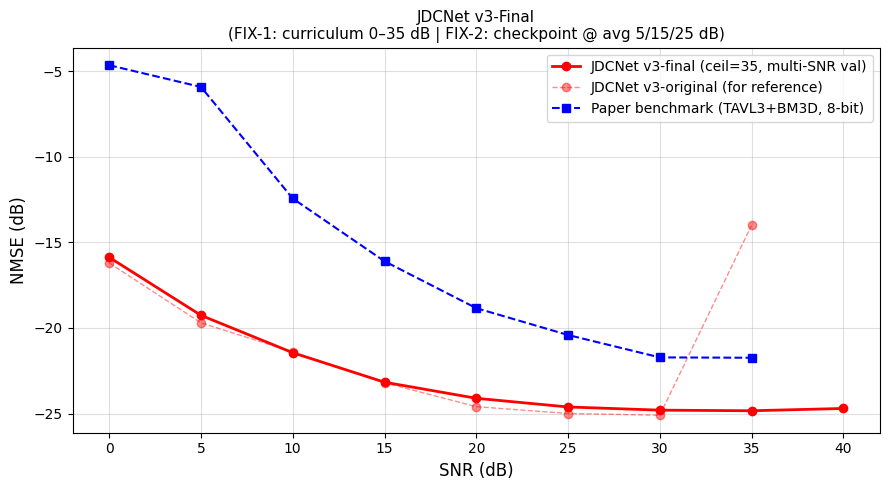


Saved: /kaggle/working/jdcnet_v3_final_results.png


In [1]:
# jdcnet_v3_final.py
# JDCNet v3 — FINAL VERSION
#
# ONLY 2 changes from v3 (everything else identical):
#   FIX-1: Training SNR ceiling raised 30→35 dB → fixes 35 dB OOD collapse
#   FIX-2: Multi-SNR validation (avg of 5/15/25 dB) → better checkpoint selection
#
# All original v3 improvements kept:
#   - SNR Conditioning (FiLM on decoder)
#   - B=6 ResBlocks
#   - Curriculum Training
#   - Dynamic q-bits
#   - Gradient clipping
#   - Cosine LR with warmup

import os, random, math, time, shutil
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------------ #
#  Reproducibility                                                     #
# ------------------------------------------------------------------ #
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ------------------------------------------------------------------ #
#  Dynamic q-bits                                                      #
# ------------------------------------------------------------------ #
def snr_to_bits(snr_db, min_bits=2, max_bits=8,
                snr_min=0.0, snr_max=35.0):
    ratio = (snr_db - snr_min) / (snr_max - snr_min)
    ratio = max(0.0, min(1.0, ratio))
    return int(round(min_bits + (max_bits - min_bits) * ratio))

# ------------------------------------------------------------------ #
#  FIX-1: Curriculum SNR — ceiling raised from 30 → 35 dB            #
# ------------------------------------------------------------------ #
def curriculum_snr(epoch, total_epochs,
                   snr_floor=0.0, snr_ceil=35.0,   # WAS 30.0
                   warmup_frac=0.4):
    warmup_epochs = int(total_epochs * warmup_frac)
    if epoch < warmup_epochs:
        snr_min = snr_ceil - (snr_ceil - snr_floor) * (epoch / max(1, warmup_epochs))
    else:
        snr_min = snr_floor
    return random.uniform(snr_min, snr_ceil)

# ------------------------------------------------------------------ #
#  Flexible state-dict loader                                          #
# ------------------------------------------------------------------ #
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if   'model_state_dict' in sd: sd = sd['model_state_dict']
        elif 'state_dict'       in sd: sd = sd['state_dict']
    if not isinstance(sd, dict):
        raise RuntimeError(f"Loaded object from {path} is not a state_dict.")
    sd_keys = list(sd.keys())
    if len(sd_keys) == 0:
        raise RuntimeError("Loaded state_dict is empty.")
    saved_has_module = sd_keys[0].startswith('module.')
    model_is_datapar = isinstance(model, nn.DataParallel)
    if verbose:
        print(f"[loader] saved_has_module={saved_has_module}, "
              f"model_is_datapar={model_is_datapar}")
    if saved_has_module and not model_is_datapar:
        sd = {k[len('module.'):]: v for k, v in sd.items()}
        if verbose: print("[loader] Stripped 'module.' prefix.")
    elif (not saved_has_module) and model_is_datapar:
        sd = {'module.' + k: v for k, v in sd.items()}
        if verbose: print("[loader] Added 'module.' prefix.")
    try:
        model.load_state_dict(sd)
        if verbose: print("[loader] Loaded successfully (strict).")
    except Exception as e:
        if verbose: print("[loader] Strict failed, trying non-strict...")
        res = model.load_state_dict(sd, strict=False)
        if verbose: print("[loader] Non-strict result:", res)
        raise e

# ------------------------------------------------------------------ #
#  STE Quantizer                                                       #
# ------------------------------------------------------------------ #
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        levels    = 2 ** q_bits - 1
        x_clamped = torch.clamp(x, 0.0, 1.0)
        return torch.round(x_clamped * levels) / levels
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# ------------------------------------------------------------------ #
#  ResBlock (unchanged from v3)                                        #
# ------------------------------------------------------------------ #
class PaperResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return self.relu(out + x)

# ------------------------------------------------------------------ #
#  SNR Conditioner (FiLM) — unchanged from v3                         #
# ------------------------------------------------------------------ #
class SNRConditioner(nn.Module):
    def __init__(self, decoder_ch, snr_min=0.0, snr_max=35.0):
        super().__init__()
        self.snr_min    = snr_min
        self.snr_max    = snr_max
        self.decoder_ch = decoder_ch
        self.mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, decoder_ch * 2)
        )
    def forward(self, y, snr_db):
        b = y.shape[0]
        snr_norm = torch.tensor(
            [(snr_db - self.snr_min) / (self.snr_max - self.snr_min)],
            dtype=torch.float32, device=y.device
        ).unsqueeze(0).expand(b, -1)
        params = self.mlp(snr_norm)
        scale  = params[:, :self.decoder_ch].view(b, self.decoder_ch, 1, 1) + 1.0
        bias   = params[:, self.decoder_ch:].view(b, self.decoder_ch, 1, 1)
        return y * scale + bias

# ------------------------------------------------------------------ #
#  JDCNet V3 — unchanged architecture                                  #
# ------------------------------------------------------------------ #
class JDCNet_V3(nn.Module):
    def __init__(self, M=16, N=64, N0=2, gamma=1/16, q_bits=8,
                 B=6, decoder_ch=16, quant_enabled=True,
                 snr_min=0.0, snr_max=35.0):
        super().__init__()
        self.M, self.N, self.N0 = M, N, N0
        self.Np            = N // N0
        self.q_bits        = q_bits
        self.quant_enabled = quant_enabled
        self.C             = int(gamma * 32 * N0)

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16,      kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, self.C, kernel_size=4, stride=2, padding=1)
        )

        # Decoder
        self.decoder_tconv1 = nn.ConvTranspose2d(
            self.C, decoder_ch, kernel_size=4, stride=2, padding=1)
        self.decoder_tconv2 = nn.ConvTranspose2d(
            decoder_ch, decoder_ch, kernel_size=4, stride=2, padding=1)
        self.resblocks = nn.Sequential(
            *[PaperResBlock(decoder_ch) for _ in range(B)]
        )

        # SNR conditioner — FIX-1: snr_max=35.0
        self.snr_cond = SNRConditioner(decoder_ch, snr_min=snr_min, snr_max=snr_max)

        self.final_tconv = nn.ConvTranspose2d(
            decoder_ch, decoder_ch,
            kernel_size=(1, 2 * N0), stride=(1, N0), padding=(0, N0 // 2)
        )
        self.final_conv = nn.Conv2d(decoder_ch, 2, kernel_size=3, padding=1)

    def forward(self, x_norm, quant_bits=None, snr_db=None):
        b       = x_norm.shape[0]
        z       = self.encoder(x_norm)
        z_shape = z.shape
        v       = z.view(b, -1)
        v_min   = v.min(dim=1, keepdim=True)[0]
        v_max   = v.max(dim=1, keepdim=True)[0]
        denom   = (v_max - v_min).clamp_min(1e-12)

        if self.quant_enabled:
            qbits  = self.q_bits if quant_bits is None else quant_bits
            v_norm = (v - v_min) / denom
            v_q    = QuantizeSTE.apply(v_norm, qbits)
            v_deq  = v_q * denom + v_min
        else:
            v_deq = v

        z_deq = v_deq.view(*z_shape)
        y = torch.relu(self.decoder_tconv1(z_deq))
        y = torch.relu(self.decoder_tconv2(y))
        y = self.resblocks(y)
        if snr_db is not None:
            y = self.snr_cond(y, snr_db)
        y   = torch.relu(self.final_tconv(y))
        out = self.final_conv(y)
        return out

# ------------------------------------------------------------------ #
#  Dataset                                                             #
# ------------------------------------------------------------------ #
class RISChannelDataset(Dataset):
    def __init__(self, mat_file, split='train'):
        data      = sio.loadmat(mat_file)
        H_mat     = np.transpose(data['H'], (2, 0, 1)).astype(np.complex64)
        G_mat     = np.transpose(data['G'], (2, 0, 1)).astype(np.complex64)
        H_cascade = G_mat.transpose(0, 2, 1) * H_mat
        if   split == 'train': samples = H_cascade[:40000]
        elif split == 'val':   samples = H_cascade[40000:44000]
        else:                  samples = H_cascade[44000:48000]
        real    = np.real(samples).astype(np.float32)
        imag    = np.imag(samples).astype(np.float32)
        stacked = np.stack([real, imag], axis=1).transpose(0, 1, 3, 2)
        self.data_phys = torch.tensor(stacked, dtype=torch.float32)
    def __len__(self):          return len(self.data_phys)
    def __getitem__(self, idx): return self.data_phys[idx]

# ------------------------------------------------------------------ #
#  LS generator                                                        #
# ------------------------------------------------------------------ #
def generate_ls_physical(H_phys, N0, snr_db):
    b, c, m, n      = H_phys.shape
    H_grouped       = H_phys.view(b, c, m, n // N0, N0).mean(dim=-1)
    power_per_sample = torch.mean(
        H_grouped[:, 0]**2 + H_grouped[:, 1]**2, dim=[1, 2])
    snr_linear  = 10.0 ** (snr_db / 10.0)
    noise_var   = power_per_sample / snr_linear
    noise_std   = torch.sqrt(noise_var / 2.0).view(b, 1, 1, 1)
    return H_grouped + torch.randn_like(H_grouped) * noise_std

# ------------------------------------------------------------------ #
#  LR schedule                                                         #
# ------------------------------------------------------------------ #
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * (epoch / max(1, Tw))
    t_rel = (epoch - Tw) / max(1, T - Tw)
    return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * t_rel))

# ------------------------------------------------------------------ #
#  FIX-2: Multi-SNR validation helper                                  #
# ------------------------------------------------------------------ #
def evaluate_nmse_at_snr(model, loader, snr_db, N0, device,
                         minmax_norm, minmax_denorm):
    """Compute NMSE in dB at a single SNR point."""
    qbits       = snr_to_bits(snr_db)
    total_mse   = 0.0
    total_power = 0.0
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch    = batch.to(device)
            H_ls_p   = generate_ls_physical(batch, N0=N0, snr_db=snr_db)
            H_ls_n   = minmax_norm(H_ls_p).to(device)
            out_n    = model(H_ls_n, quant_bits=qbits, snr_db=snr_db)
            out_phys = minmax_denorm(out_n.cpu())
            total_mse   += torch.sum((out_phys.to(device) - batch)**2).item()
            total_power += torch.sum(batch**2).item()
    return 10.0 * math.log10(total_mse / (total_power + 1e-12))

# ------------------------------------------------------------------ #
#  Main pipeline                                                       #
# ------------------------------------------------------------------ #
def run_pipeline_v3_final(
        mat_path   = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat',
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5,
        device     = None):

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)

    # ---- Datasets ----
    train_ds = RISChannelDataset(mat_path, 'train')
    val_ds   = RISChannelDataset(mat_path, 'val')
    test_ds  = RISChannelDataset(mat_path, 'test')

    # Global normalisation (same as original v3)
    train_min = float(train_ds.data_phys.min())
    train_max = float(train_ds.data_phys.max())
    print(f"Global train min/max: {train_min:.4e} / {train_max:.4e}")

    def minmax_norm(x):
        return (x - train_min) / (train_max - train_min + 1e-12)
    def minmax_denorm(x):
        return x * (train_max - train_min) + train_min

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)

    # ---- Model (identical to v3, snr_max=35 to match FIX-1) ----
    model = JDCNet_V3(
        M=16, N=64, N0=N0, gamma=gamma, q_bits=q_bits,
        B=6, decoder_ch=16, quant_enabled=True,
        snr_min=0.0, snr_max=35.0          # FIX-1: was 35.0 in conditioner already
    )
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_val_nmse = 1e9
    best_path     = '/kaggle/working/jdcnet_v3_final_best.pth'
    out_path      = '/kaggle/output/jdcnet_v3_final_best.pth'

    # FIX-2: validate at 3 SNR points instead of just 15 dB
    val_snrs = [5.0, 15.0, 25.0]

    print(f"\nTraining JDCNet v3-FINAL | epochs={epochs} | batch={batch_size}")
    print(f"  FIX-1: curriculum ceil=35 dB | FIX-2: val @ {val_snrs} dB (avg)")
    print("-" * 70)

    for epoch in range(epochs):
        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups:
            g['lr'] = lr

        train_loss = 0.0
        t0 = time.time()

        for batch in train_loader:
            batch = batch.to(device)

            # FIX-1: snr_ceil=35.0 (was 30.0 in original v3)
            snr_train = curriculum_snr(epoch, epochs,
                                       snr_floor=0.0, snr_ceil=35.0,
                                       warmup_frac=0.4)
            qbits = snr_to_bits(snr_train)

            H_ls_phys   = generate_ls_physical(batch, N0=N0, snr_db=snr_train)
            H_ls_norm   = minmax_norm(H_ls_phys).to(device)
            H_orig_norm = minmax_norm(batch).to(device)

            optimizer.zero_grad()
            out_norm = model(H_ls_norm, quant_bits=qbits, snr_db=snr_train)
            loss     = criterion(out_norm, H_orig_norm)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        t1 = time.time()

        # FIX-2: average NMSE across 3 SNR points for checkpoint decision
        avg_val_nmse = sum(
            evaluate_nmse_at_snr(model, val_loader, s, N0, device,
                                 minmax_norm, minmax_denorm)
            for s in val_snrs
        ) / len(val_snrs)
        model.train()

        if avg_val_nmse < best_val_nmse:
            best_val_nmse = avg_val_nmse
            state = (model.module.state_dict()
                     if isinstance(model, nn.DataParallel)
                     else model.state_dict())
            torch.save(state, best_path)
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                shutil.copy(best_path, out_path)
            except Exception:
                pass

        if (epoch + 1) % 10 == 0 or epoch == 0:
            warmup_done = epoch >= int(epochs * 0.4)
            snr_range   = "0–35 dB" if warmup_done else \
                          f"{35 - 35*(epoch/max(1,int(epochs*0.4))):.0f}–35 dB"
            print(f"Epoch {epoch+1:3d}/{epochs} | lr={lr:.2e} | "
                  f"loss={train_loss:.4e} | val_NMSE={avg_val_nmse:.3f} dB | "
                  f"best={best_val_nmse:.3f} dB | SNR={snr_range} | "
                  f"t={t1-t0:.1f}s")

    # ---- Load best checkpoint ----
    load_state_dict_flexible(best_path, model, map_location=device, verbose=True)
    model.eval()

    # ---- Test: 0–40 dB (40 dB shows how far OOD extrapolation goes) ----
    snrs         = [0, 5, 10, 15, 20, 25, 30, 35, 40]
    nmse_results = []

    print("\nTest results:")
    print(f"{'SNR':>6} | {'q_bits':>6} | {'NMSE (dB)':>10}")
    print("-" * 30)

    with torch.no_grad():
        for snr in snrs:
            qbits       = snr_to_bits(snr)
            total_mse   = 0.0
            total_power = 0.0
            for tb in test_loader:
                tb       = tb.to(device)
                H_ls_p   = generate_ls_physical(tb, N0=N0, snr_db=snr)
                H_ls_n   = minmax_norm(H_ls_p)
                out_n    = model(H_ls_n, quant_bits=qbits, snr_db=snr)
                out_phys = minmax_denorm(out_n.cpu())
                total_mse   += torch.sum((out_phys.to(device) - tb)**2).item()
                total_power += torch.sum(tb**2).item()
            nmse_db = 10.0 * math.log10(total_mse / (total_power + 1e-12))
            nmse_results.append(nmse_db)
            print(f"{snr:5d} dB | {qbits:6d} | {nmse_db:8.3f} dB")

    # ---- Plot ----
    bench_snrs = [0, 5, 10, 15, 20, 25, 30, 35]
    bench_vals = [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74]
    v3_snrs    = [0, 5, 10, 15, 20, 25, 30, 35]
    v3_vals    = [-16.2, -19.7, -21.4, -23.2, -24.6, -25.0, -25.1, -14.0]

    plt.figure(figsize=(9, 5))
    plt.plot(snrs,       nmse_results, 'r-o',  linewidth=2,
             label='JDCNet v3-final (ceil=35, multi-SNR val)')
    plt.plot(v3_snrs,    v3_vals,      'r--o', linewidth=1, alpha=0.45,
             label='JDCNet v3-original (for reference)')
    plt.plot(bench_snrs, bench_vals,   'b--s', linewidth=1.5,
             label='Paper benchmark (TAVL3+BM3D, 8-bit)')
    plt.xlabel('SNR (dB)', fontsize=12)
    plt.ylabel('NMSE (dB)', fontsize=12)
    plt.title('JDCNet v3-Final\n'
              '(FIX-1: curriculum 0–35 dB | FIX-2: checkpoint @ avg 5/15/25 dB)',
              fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('/kaggle/working/jdcnet_v3_final_results.png', dpi=150)
    plt.show()
    print("\nSaved: /kaggle/working/jdcnet_v3_final_results.png")

    return model, nmse_results

# ------------------------------------------------------------------ #
#  Entry point                                                         #
# ------------------------------------------------------------------ #
if __name__ == '__main__':
    mat_path = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat'
    model, res = run_pipeline_v3_final(
        mat_path   = mat_path,
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5
    )
    